### About Data
Microsoft Planetary Computer, 'https://planetarycomputer.microsoft.com/dataset/landsat-c2-l2', is where our data landsat from Palisades Eaton was retrieved.

### Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import xarray as xr
import rioxarray


### Import Data

In [2]:
# Import landsat `nc` file
landsat = xr.open_dataset('data/landsat8-2025-02-23-palisades-eaton.nc')
# Import states data
fp = os.path.join('data/eaton_perimeter/Eaton_Perimeter_20250121.shp')
eaton = gpd.read_file(fp)
fp = os.path.join('data/palisades_perimeter/Palisades_Perimeter_20250121.shp')
palisades = gpd.read_file(fp)


# Data Exploration

In [3]:
landsat.head()

<xarray.Dataset> Size: 596B
Dimensions:      (y: 5, x: 5)
Coordinates:
  * y            (y) float64 40B 3.799e+06 3.799e+06 ... 3.799e+06 3.799e+06
  * x            (x) float64 40B 3.344e+05 3.344e+05 ... 3.345e+05 3.345e+05
    time         datetime64[ns] 8B ...
Data variables:
    red          (y, x) float32 100B ...
    green        (y, x) float32 100B ...
    blue         (y, x) float32 100B ...
    nir08        (y, x) float32 100B ...
    swir22       (y, x) float32 100B ...
    spatial_ref  int64 8B ...

In [4]:
# Check CRS
print(f"CRS: {palisades.crs}") # CRS = EPSG:3857

# Check bounds
print(palisades.total_bounds)

# View first five rows
palisades.head()

CRS: EPSG:3857
[-13212082.926963     4032822.81114236 -13191297.3200706
   4046185.03346286]


,OBJECTID,type,Shape__Are,Shape__Len,geometry
0,1,Heat Perimeter,1182.082031,267.101144,"POLYGON ((-13193543.302 4032913.077, -13193543..."
1,2,Heat Perimeter,2222.488281,185.498783,"POLYGON ((-13193524.155 4033067.953, -13193524..."
2,3,Heat Perimeter,21.011719,22.412814,"POLYGON ((-13193598.085 4033158.222, -13193598..."
3,4,Heat Perimeter,214.992188,76.639180,"POLYGON ((-13193654.249 4033146.033, -13193656..."
4,5,Heat Perimeter,44203.453125,1569.259764,"POLYGON ((-13194209.580 4033236.320, -13194209..."


In [5]:
# Check CRS
print(f"CRS: {eaton.crs}") # CRS = EPSG:3857

# Check bounds
print(eaton.total_bounds)

# View first five rows
eaton.head()

CRS: EPSG:3857
[-13153741.463466     4050560.93661453 -13137152.8556185
   4060781.94401591]


,OBJECTID,type,Shape__Are,Shape__Len,geometry
0,1,Heat Perimeter,2206.265625,270.199719,"POLYGON ((-13146936.686 4051222.067, -13146932..."
1,2,Heat Perimeter,20710.207031,839.204218,"POLYGON ((-13150835.463 4052713.929, -13150831..."
2,3,Heat Perimeter,3639.238281,250.304502,"POLYGON ((-13153094.697 4053057.596, -13153113..."
3,4,Heat Perimeter,1464.550781,148.106792,"POLYGON ((-13145097.740 4053118.235, -13145100..."
4,5,Heat Perimeter,4132.753906,247.960744,"POLYGON ((-13153131.126 4053196.882, -13153131..."


In [6]:
# Lower column titles on dataframes
for df in [palisades, eaton]:
    df.columns = df.columns.str.lower()


<Axes: >

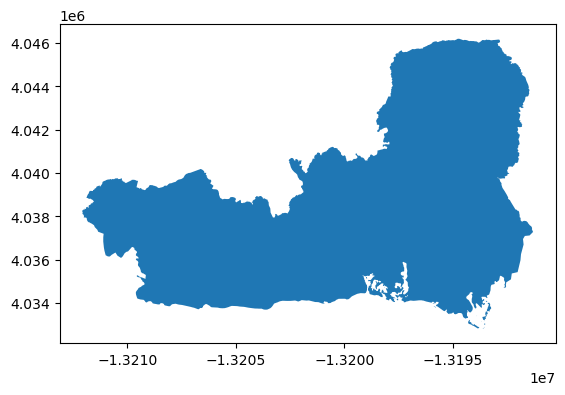

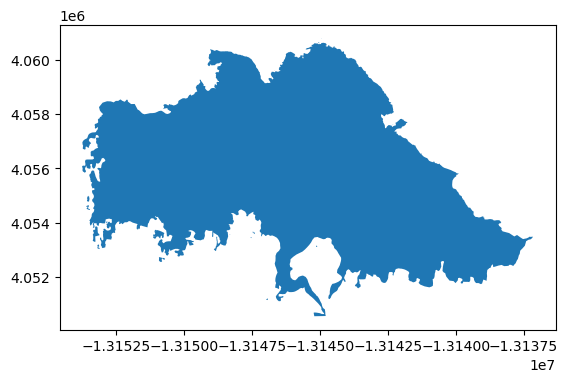

In [7]:
# View DF map
palisades.plot()

# Second Map
eaton.plot()


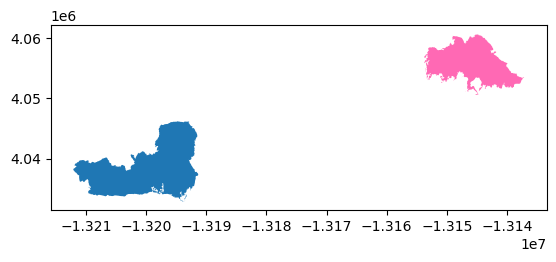

In [8]:
fig, ax = plt.subplots()

palisades.plot(ax=ax)
eaton.plot(ax=ax, color = 'hotpink')

plt.show()

In [9]:
print(f"{'Is the CRS geographic?' : <25} {palisades.crs.is_geographic}")
print(f"{'Is the CRS projected?' : <25} {palisades.crs.is_projected}")

print(f"{'Is the CRS geographic?' : <25} {eaton.crs.is_geographic}")
print(f"{'Is the CRS projected?' : <25} {eaton.crs.is_projected}")

Is the CRS geographic?    False
Is the CRS projected?     True
Is the CRS geographic?    False
Is the CRS projected?     True


#### Summary:
Through my preliminary data exploration I was able to know the bounding box for both fire perimeters (Palisades and Eaton). Both datasets have the same CRS, I also changed the name of the columns on both datasets to be lowered. I also viewed the landsat, nc file, to view the dimensions and noticed it had floats on the x and y axis, as well as a datetime series for time. 

# Restoring geospatial information

In [10]:
# Check CRS of Landsat
print(f"CRS:, {landsat.rio.crs}")

# Extract CRS using spatial_ref variable
wkt = landsat.spatial_ref.crs_wkt
print("\nCRS WKT from spatial_ref:")
print(wkt)

# Write the CRS to the dataset - geospatial information and spatial reference
landsat = landsat.rio.write_crs(wkt, inplace=False)

# Verify CRS is now attached
print("\nCRS after writing:", landsat.rio.crs)


CRS:, None

CRS WKT from spatial_ref:
PROJCS["WGS 84 / UTM zone 11N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32611"]]

CRS after writing: EPSG:32611


# True color image

/opt/anaconda3/envs/eds220-env/lib/python3.11/site-packages/matplotlib/cm.py:478: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


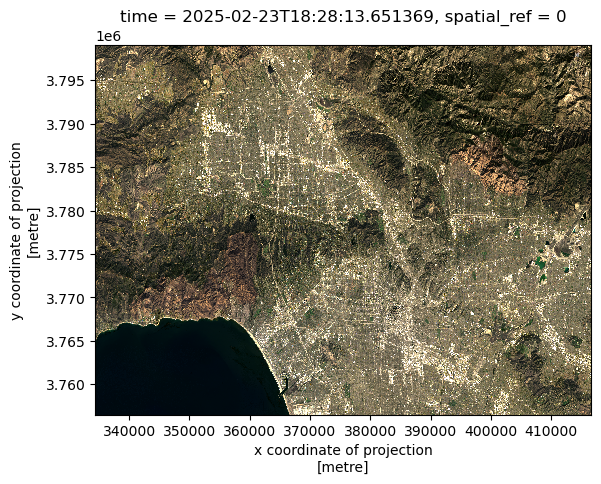

In [11]:
# Select RGB bands
rgb = landsat[["red", "green", "blue"]]

# Convert to numpy.array 
rgb_array = rgb.to_array()

# Plot with robust=True (handles outliers like clouds)
rgb_array.plot.imshow(robust = True)

In [12]:
# Identify which bands have NAN values
np.isnan(rgb_array).any(dim=["x", "y"])


<xarray.DataArray (variable: 3)> Size: 3B
array([False,  True,  True])
Coordinates:
    time         datetime64[ns] 8B 2025-02-23T18:28:13.651369
    spatial_ref  int64 8B 0
  * variable     (variable) object 24B 'red' 'green' 'blue'

In [13]:
# Check `nan` values in a for-loop
for band in ["red", "green", "blue"]:
    print(band, landsat[band].isnull().any().item())


red False
green True
blue True


In [14]:
#  Substitue any NAN values as 0
landsat_filled = landsat.fillna(0)

# Add fillna() back into rgb
rgb_filled = landsat_filled[["red", "green", "blue"]].to_array()


/opt/anaconda3/envs/eds220-env/lib/python3.11/site-packages/matplotlib/cm.py:478: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


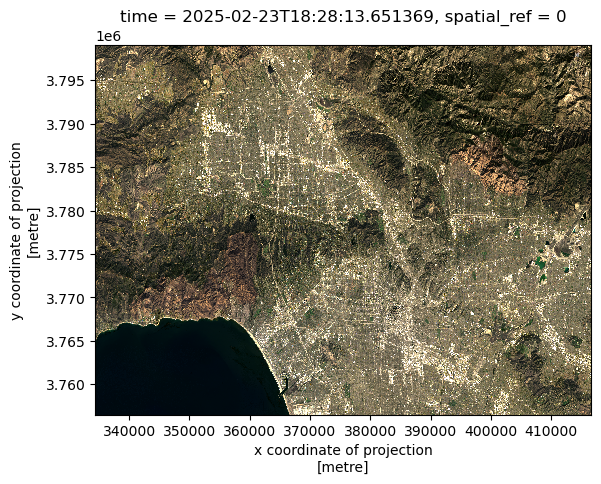

In [15]:
rgb_array.plot.imshow(robust = True)

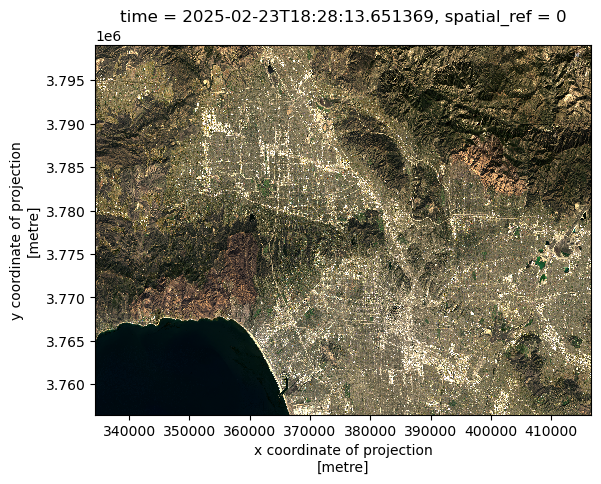

In [16]:
# Plot it
rgb_filled.plot.imshow(robust=True)

The first output, warning message were given aswell as the bands had NaN values which caused the errors as well as not accounting for cloud coverage, reflections, missing pixels, and shadows. In the second output, after replacing NaN values, the message no longer shows, the image has no missing pixels and it is clearer.

# False color image
Without creating any new variables, create a false color image by plotting the short-wave infrared (swir22), near-infrared, and red variables (in that order).

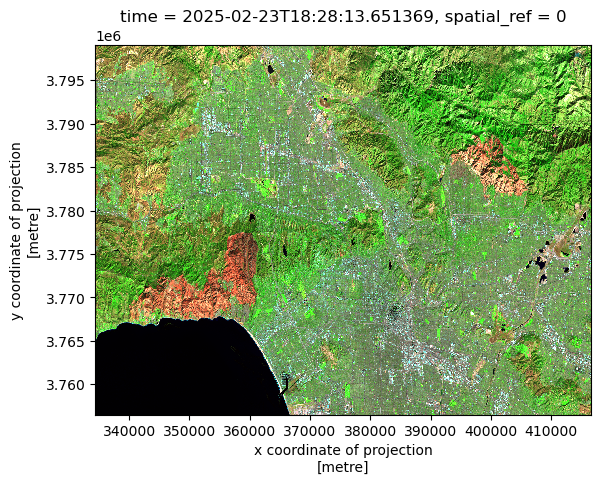

In [17]:
# Use chaining method - Convert to numpy array, then plot
landsat[['swir22', 'nir08', 'red']].to_array().plot.imshow(robust=True)


# Map
- Create a map showing the shortwave infrared/near-infrared/red false color image together with both fire perimeters. 
- Customize it appropriately including, at least, an informative title and legend. You may also want to include text on the map to identify which fire is which.

Write a figure description for the map including a brief explanation of how false color imagery is being used.

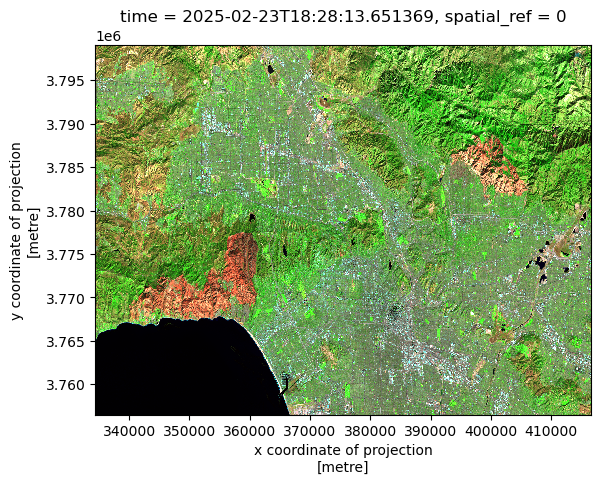

In [18]:
# Assign numpy array to a variable
false_color = landsat[["swir22", "nir08", "red"]].to_array()

# Plot it
false_color.plot.imshow(robust=True)

In [19]:
print(landsat.rio.crs)


EPSG:32611


In [20]:
print("Eaton CRS:", eaton.crs)

Eaton CRS: EPSG:3857


In [21]:
print("Palisades CRS:", palisades.crs)

Palisades CRS: EPSG:3857


In [22]:
# Transform Fire Perimeters
eaton = eaton.to_crs(landsat.rio.crs)
palisades = palisades.to_crs(landsat.rio.crs)

# Check transformation
print("Eaton CRS:", eaton.crs)
print("Palisades CRS:", palisades.crs)

Eaton CRS: PROJCS["WGS 84 / UTM zone 11N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32611"]]
Palisades CRS: PROJCS["WGS 84 / UTM zone 11N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central

In [23]:
# Reordering the axes of xarray DataArray
rgb = false_color.transpose("y","x","variable").values.astype(float)

In [24]:
# Clip outliers: Issues were given if not used
vmin = np.percentile(rgb, 2)
vmax = np.percentile(rgb, 98)
rgb = np.clip(rgb, vmin, vmax)
rgb = (rgb - vmin) / (vmax - vmin)

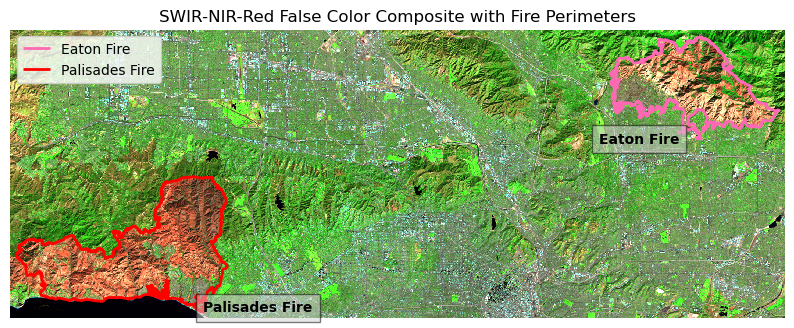

In [93]:
# Set up fig, ax
fig, ax = plt.subplots(figsize=(10,10))

# Plot false-color background first
false_color.plot.imshow(robust=True)

# Overlay fire perimeters
eaton.boundary.plot(ax=ax, color="hotpink", linewidth=2, label="Eaton Fire")
palisades.boundary.plot(ax=ax, color="red", linewidth=2, label="Palisades Fire")


# Add label for Eaton fire perimeter
ax.text(eaton.geometry.centroid.iloc[0].x,
        eaton.geometry.centroid.iloc[0].y,
        "Eaton Fire", color="black", fontsize=10, weight="bold", bbox=dict(facecolor='lightgrey', alpha=0.5, pad=5),
        # Horizontal alignment
        ha = "right",
        # Vertical alignment
        va = "top")

# Add labels for Palisades fire perimeter
ax.text(palisades.geometry.centroid.iloc[0].x,
        palisades.geometry.centroid.iloc[0].y,
        "Palisades Fire", color="black", fontsize=10, weight="bold", bbox=dict(facecolor='lightgrey', alpha=0.5, pad=5), 
        # Horizontal alignment
        ha = "left",
        # Vertical alignment
        va = "baseline")

# Zoom to fire extents - Need Perimeters do not show
xmin = min(eaton.total_bounds[0], palisades.total_bounds[0]) - 500
xmax = max(eaton.total_bounds[2], palisades.total_bounds[2]) + 500
ymin = min(eaton.total_bounds[1], palisades.total_bounds[1]) - 500
ymax = max(eaton.total_bounds[3], palisades.total_bounds[3]) + 500

# Set limits
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax) 

# Title
ax.set_title("SWIR-NIR-Red False Color Composite with Fire Perimeters")
# Legend
ax.legend(loc = "upper left")
ax.set_axis_off()
plt.show()